# Exploratory Data Analysis (EDA)
## GEDEvent Dataset - v25.1

This notebook provides a comprehensive exploratory data analysis of the GEDEvent dataset, which contains geopolitical events data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Basic Information

In [2]:
# Load dataset
df = pd.read_csv('GEDEvent_v25_1.csv')

# Display basic information
print("Dataset Shape:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nTotal Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset Shape:
Rows: 385,918
Columns: 49

Total Memory Usage: 703.20 MB


In [3]:
# Data types
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
id                     int64
relid                    str
year                   int64
active_year             bool
code_status              str
type_of_violence       int64
conflict_dset_id       int64
conflict_new_id        int64
conflict_name            str
dyad_dset_id           int64
dyad_new_id            int64
dyad_name                str
side_a_dset_id         int64
side_a_new_id          int64
side_a                   str
side_b_dset_id         int64
side_b_new_id          int64
side_b                   str
number_of_sources      int64
source_article           str
source_office            str
source_date              str
source_headline          str
source_original          str
where_prec             int64
where_coordinates        str
where_description        str
adm_1                    str
adm_2                    str
latitude             float64
longitude            float64
geom_wkt                 str
priogrid_gid           int64
country                

In [4]:
# First few rows
print("\n=== First Few Rows ===")
df.head()


=== First Few Rows ===


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29 00:00:00.000,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN


## 2. Missing Values Analysis

In [5]:
# Missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print("\n=== Missing Values ===")
print(missing_data if len(missing_data) > 0 else "No missing values found!")


=== Missing Values ===
                              Column  Missing_Count  Missing_Percentage
gwnob                          gwnob         355662               92.16
source_headline      source_headline          97918               25.37
source_date              source_date          97913               25.37
source_office          source_office          97913               25.37
gwnoa                          gwnoa          93411               24.20
adm_2                          adm_2          69977               18.13
source_original      source_original          44244               11.46
adm_1                          adm_1          19547                5.07
where_description  where_description          10243                2.65
source_article        source_article              1                0.00


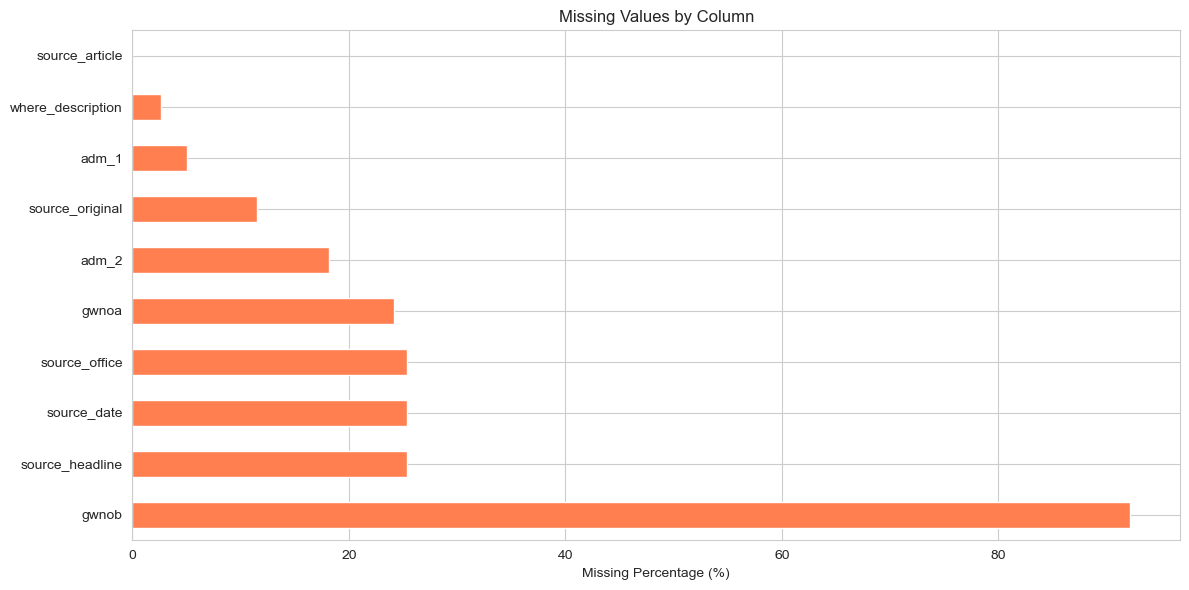

In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_percent = (df.isnull().sum() / len(df) * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

if len(missing_percent) > 0:
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
else:
    ax.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Missing Values by Column')

plt.show()

## 3. Summary Statistics

In [7]:
# Numerical columns summary
print("\n=== Summary Statistics (Numerical Columns) ===")
df.describe().round(2)


=== Summary Statistics (Numerical Columns) ===


,id,year,type_of_violence,conflict_dset_id,conflict_new_id,dyad_dset_id,dyad_new_id,side_a_dset_id,side_a_new_id,side_b_dset_id,...,event_clarity,date_prec,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnob
count,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,...,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,30256.00
mean,290595.57,2012.49,1.45,3876.81,3893.46,6744.22,6993.74,633.19,633.19,3296.49,...,1.08,1.22,2.47,2.25,3.82,1.72,10.25,15.12,8.54,389.52
std,158412.34,9.41,0.75,5885.53,5774.83,6468.05,6475.38,1705.34,1705.34,3658.77,...,0.27,0.65,254.72,53.76,178.40,99.62,347.68,426.86,313.66,85.85
min,2.00,1989.00,1.00,6.00,205.00,6.00,406.00,3.00,3.00,3.00,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
25%,162928.25,2007.00,1.00,299.00,299.00,735.00,781.00,109.00,109.00,303.00,...,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,369.00
50%,293210.50,2014.00,1.00,333.00,386.00,5188.00,5226.00,118.00,118.00,775.00,...,1.00,1.00,0.00,0.00,0.00,0.00,2.00,2.00,2.00,369.00
75%,422042.75,2020.00,2.00,5583.00,4979.00,14117.00,14117.00,154.00,154.00,5914.00,...,1.00,1.00,0.00,1.00,1.00,0.00,4.00,5.00,4.00,369.00
max,572006.00,2024.00,3.00,18362.00,16527.00,18362.00,18362.00,9363.00,9363.00,9999.00,...,2.00,5.00,121848.00,19874.00,40000.00,48183.00,121848.00,121848.00,121848.00,800.00


In [8]:
# Categorical columns
print("\n=== Categorical Columns Information ===")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:5]:  # Show first 5
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())


=== Categorical Columns Information ===

relid: 385918 unique values
relid
IRQ-2017-1-524-322    1
IRQ-2021-1-524-145    1
IRQ-2021-1-524-143    1
IRQ-2021-1-524-144    1
AFG-1989-1-411-2      1
Name: count, dtype: int64

code_status: 1 unique values
code_status
Clear    385918
Name: count, dtype: int64

conflict_name: 1529 unique values
conflict_name
Syria: Government          66186
Afghanistan: Government    37828
Russia - Ukraine           28499
Turkey: Kurdistan           7620
Israel: Palestine           7353
Name: count, dtype: int64

dyad_name: 1771 unique values
dyad_name
Government of Syria - Syrian insurgents                        66186
Government of Afghanistan - Taleban                            35745
Government of Russia (Soviet Union) - Government of Ukraine    28499
Government of Turkey - PKK                                      7620
Government of India - Kashmir insurgents                        7237
Name: count, dtype: int64

side_a: 966 unique values
side_a
Governme

## 4. Key Numerical Features Analysis

In [9]:
# Deaths analysis
death_cols = ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low']

print("\n=== Deaths Statistics ===")
print(df[death_cols].describe().round(2))


=== Deaths Statistics ===
        deaths_a   deaths_b  deaths_civilians  deaths_unknown       best  \
count  385918.00  385918.00         385918.00       385918.00  385918.00   
mean        2.47       2.25              3.82            1.72      10.25   
std       254.72      53.76            178.40           99.62     347.68   
min         0.00       0.00              0.00            0.00       0.00   
25%         0.00       0.00              0.00            0.00       1.00   
50%         0.00       0.00              0.00            0.00       2.00   
75%         0.00       1.00              1.00            0.00       4.00   
max    121848.00   19874.00          40000.00        48183.00  121848.00   

            high        low  
count  385918.00  385918.00  
mean       15.12       8.54  
std       426.86     313.66  
min         0.00       0.00  
25%         1.00       1.00  
50%         2.00       2.00  
75%         5.00       4.00  
max    121848.00  121848.00  


In [10]:
# Year analysis
print("\n=== Year Range ===")
print(f"Start Year: {df['year'].min()}")
print(f"End Year: {df['year'].max()}")
print(f"Total Years: {df['year'].max() - df['year'].min() + 1}")
print(f"\nEvents per Year:")
print(df['year'].value_counts().sort_index().tail(10))


=== Year Range ===
Start Year: 1989
End Year: 2024
Total Years: 36

Events per Year:
year
2015    19875
2016    17374
2017    16304
2018    13510
2019    13841
2020    13432
2021    17254
2022    20774
2023    26486
2024    28816
Name: count, dtype: int64


In [11]:
# Geographic distribution
print("\n=== Geographic Distribution ===")
print(f"\nTotal Countries: {df['country'].nunique()}")
print(f"\nTop 10 Countries by Events:")
print(df['country'].value_counts().head(10))

print(f"\nTotal Regions: {df['region'].nunique()}")
print(f"\nTop Regions:")
print(df['region'].value_counts().head(10))


=== Geographic Distribution ===

Total Countries: 124

Top 10 Countries by Events:
country
Syria                 87861
Afghanistan           42220
Ukraine               31547
Mexico                21550
India                 17997
Colombia              14620
Iraq                   9438
Bosnia-Herzegovina     9340
DR Congo (Zaire)       8901
Myanmar (Burma)        8476
Name: count, dtype: int64

Total Regions: 5

Top Regions:
region
Middle East    122215
Asia            97879
Africa          68354
Americas        48884
Europe          48586
Name: count, dtype: int64


## 5. Distributions and Visualizations

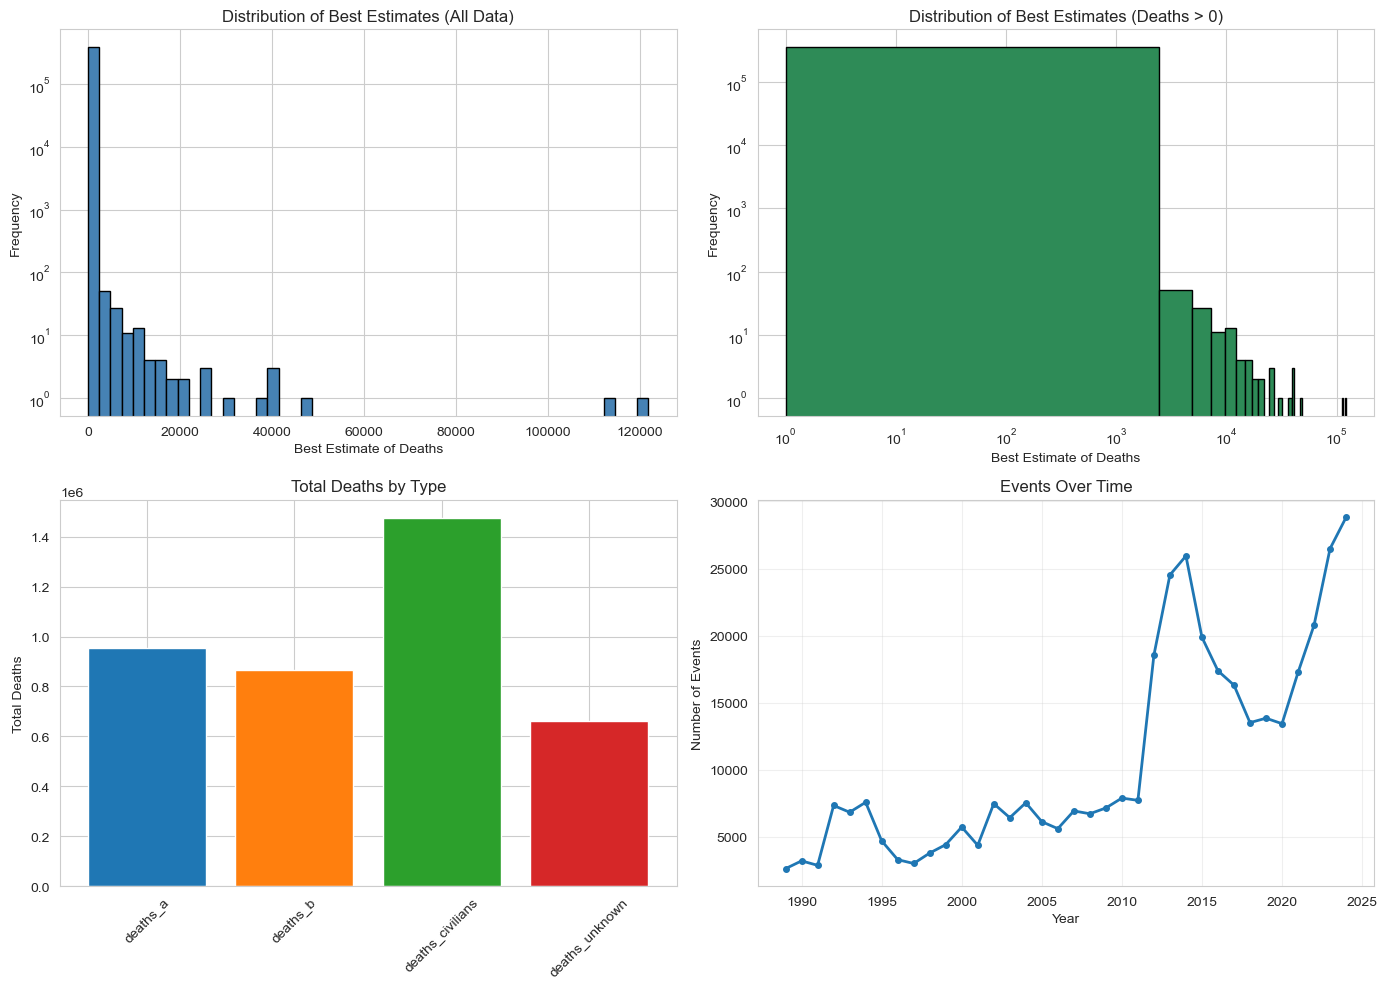

In [12]:
# Distribution of best estimates of deaths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Best deaths
axes[0, 0].hist(df['best'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Best Estimate of Deaths')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Best Estimates (All Data)')
axes[0, 0].set_yscale('log')

# Best deaths (log scale on x)
axes[0, 1].hist(df[df['best'] > 0]['best'], bins=50, color='seagreen', edgecolor='black')
axes[0, 1].set_xlabel('Best Estimate of Deaths')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Best Estimates (Deaths > 0)')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')

# Deaths by type
death_by_type = df[['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown']].sum()
axes[1, 0].bar(death_by_type.index, death_by_type.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 0].set_ylabel('Total Deaths')
axes[1, 0].set_title('Total Deaths by Type')
axes[1, 0].tick_params(axis='x', rotation=45)

# Events per year
events_per_year = df['year'].value_counts().sort_index()
axes[1, 1].plot(events_per_year.index, events_per_year.values, marker='o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Events')
axes[1, 1].set_title('Events Over Time')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

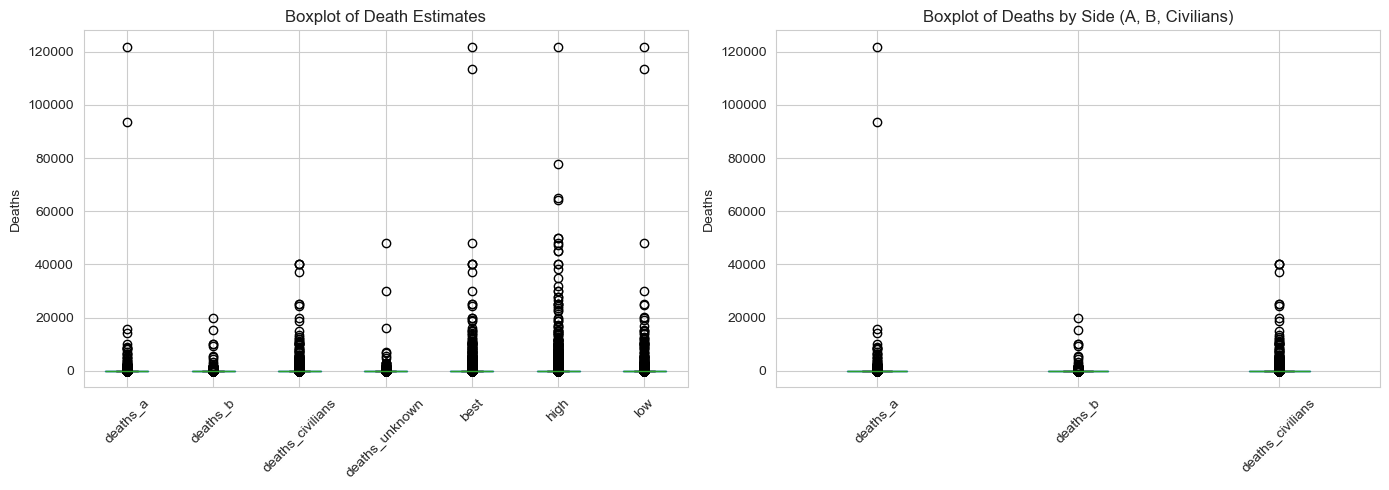

In [13]:
# Boxplots - Deaths distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot all deaths data
df[death_cols].boxplot(ax=axes[0])
axes[0].set_ylabel('Deaths')
axes[0].set_title('Boxplot of Death Estimates')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot without outliers limits
df[['deaths_a', 'deaths_b', 'deaths_civilians']].boxplot(ax=axes[1])
axes[1].set_ylabel('Deaths')
axes[1].set_title('Boxplot of Deaths by Side (A, B, Civilians)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

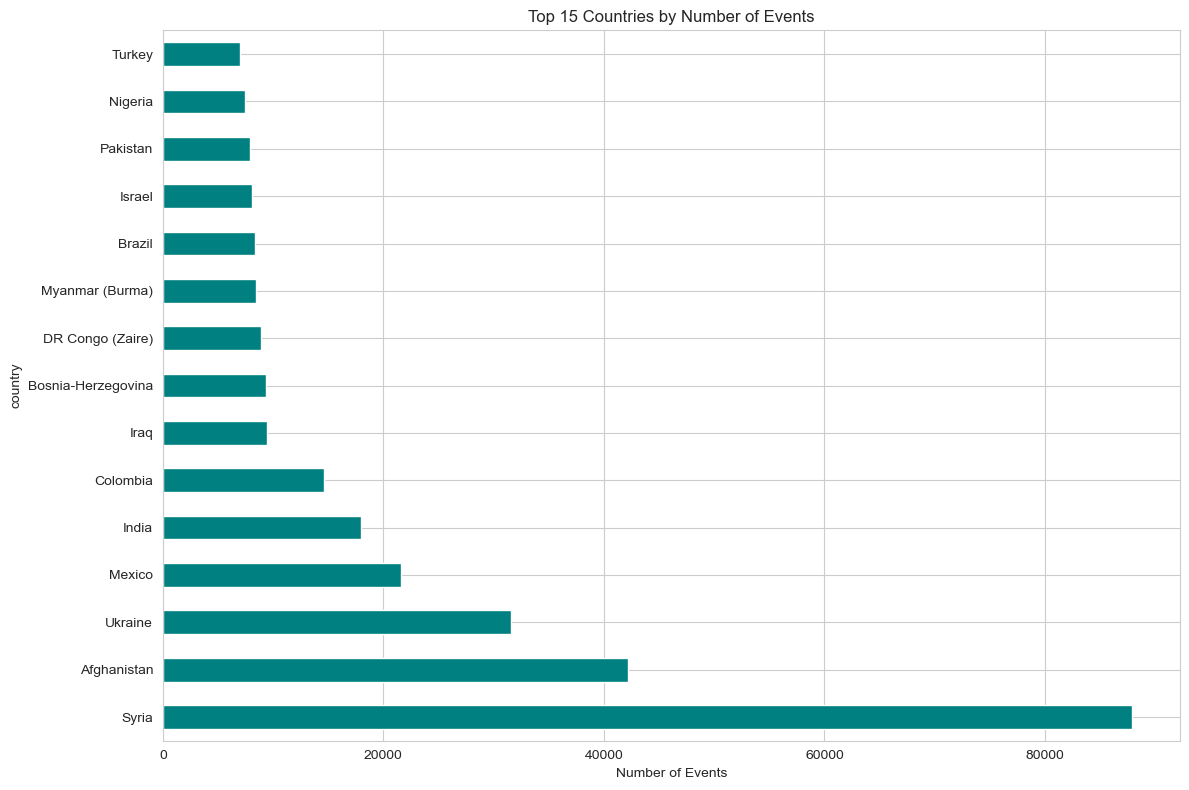

In [14]:
# Geographic visualization - Top countries
fig, ax = plt.subplots(figsize=(12, 8))
top_countries = df['country'].value_counts().head(15)
top_countries.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Number of Events')
ax.set_title('Top 15 Countries by Number of Events')
plt.tight_layout()
plt.show()

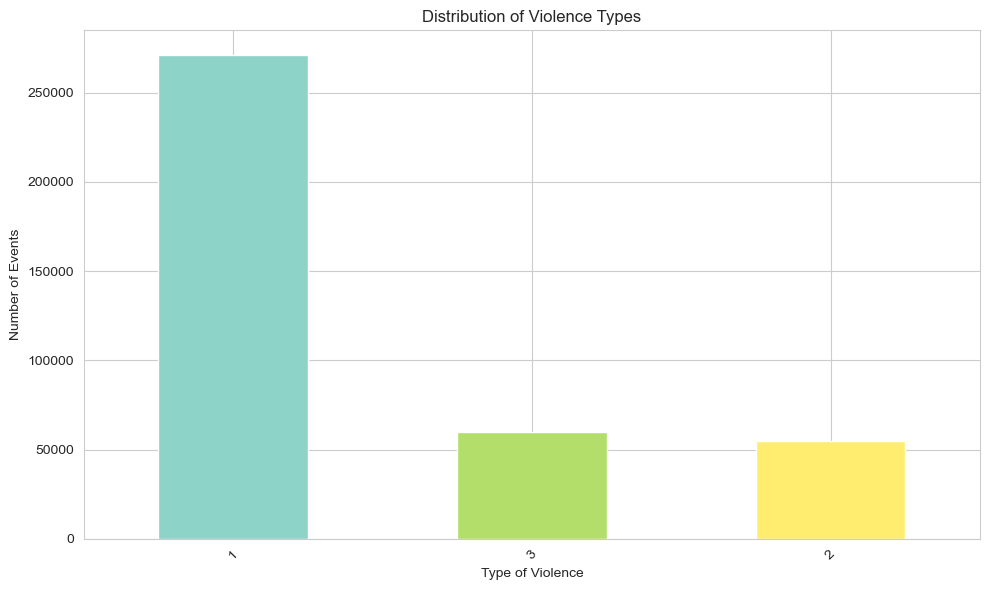

In [15]:
# Type of violence distribution
fig, ax = plt.subplots(figsize=(10, 6))
violence_types = df['type_of_violence'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(violence_types)))
violence_types.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('Number of Events')
ax.set_xlabel('Type of Violence')
ax.set_title('Distribution of Violence Types')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Correlations Analysis

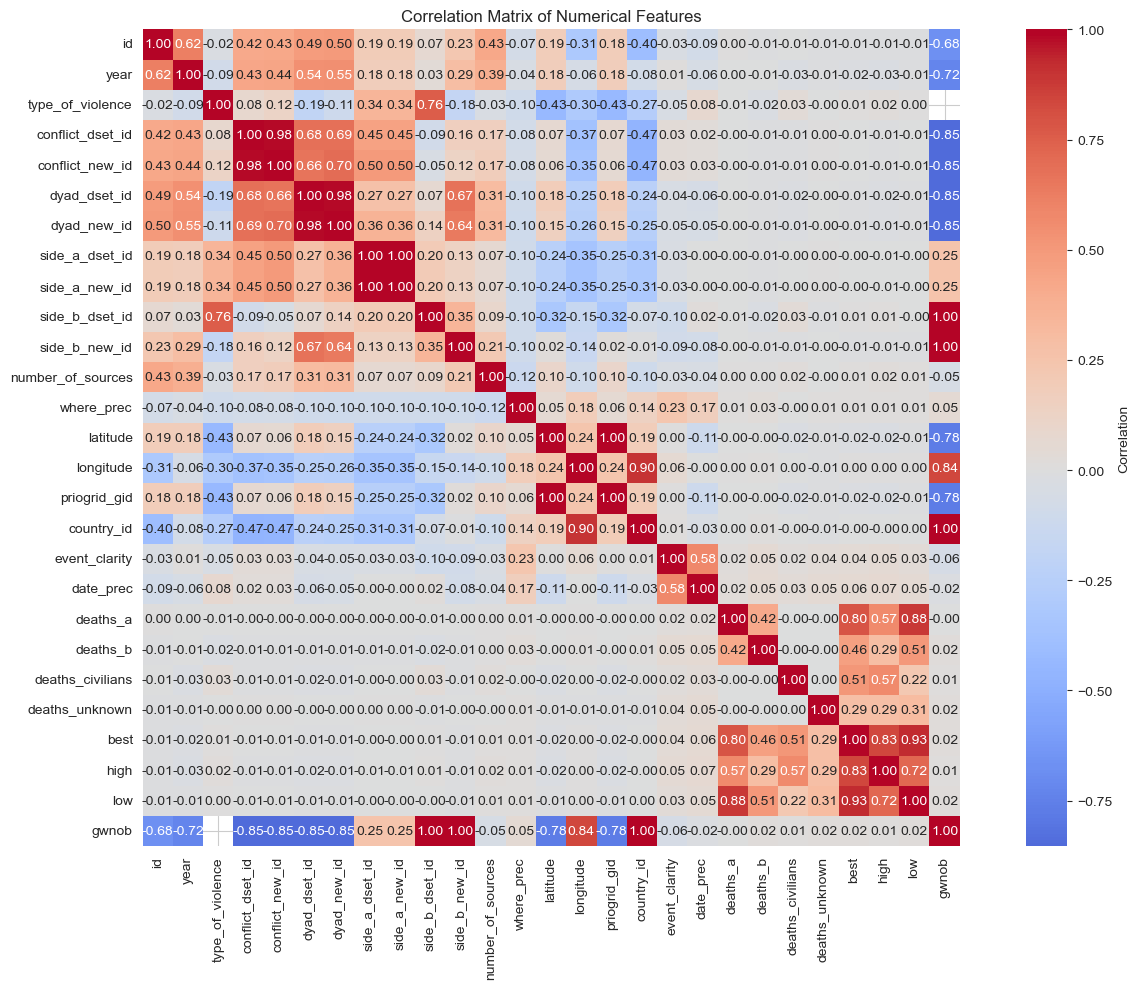

In [16]:
# Correlation matrix for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

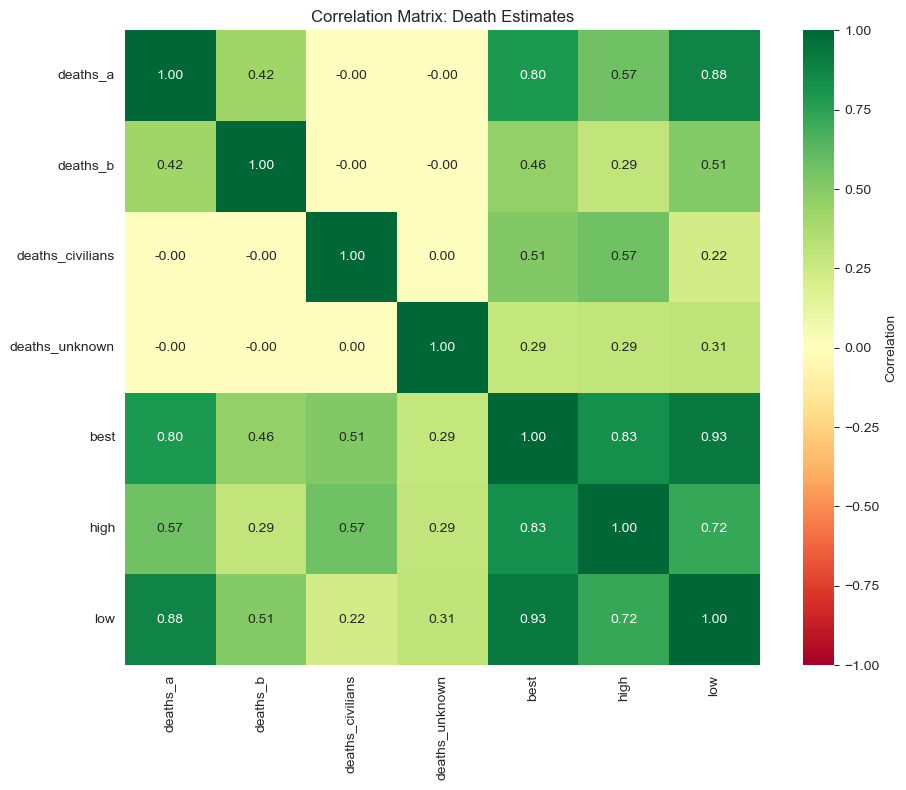

In [17]:
# Focus on deaths correlations
deaths_corr = df[death_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(deaths_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            square=True, ax=ax, vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Death Estimates')
plt.tight_layout()
plt.show()

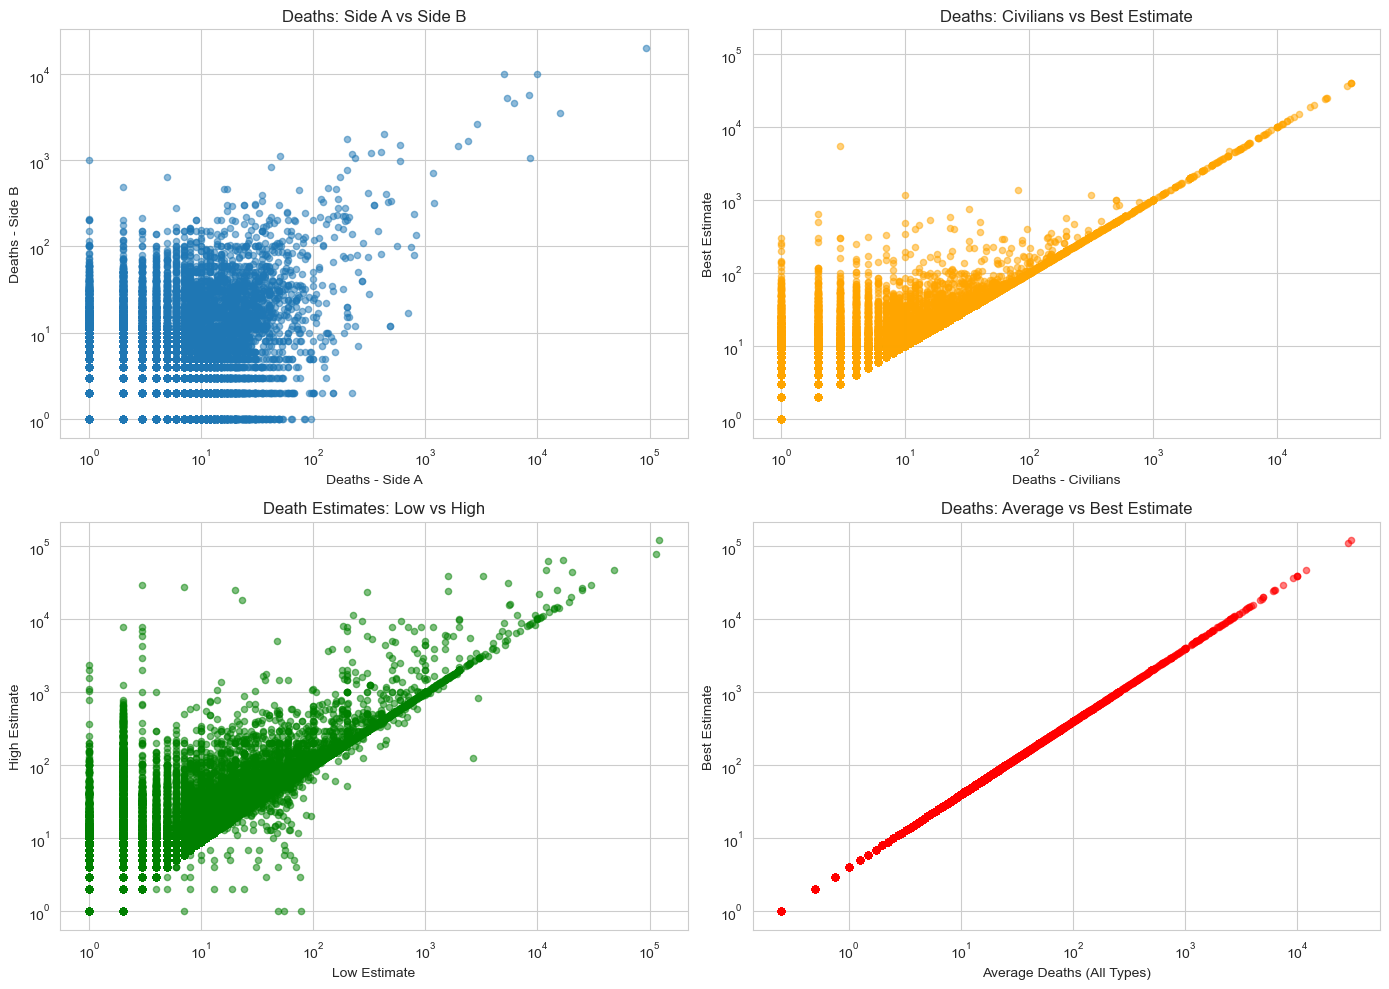

In [18]:
# Scatter plots - Relationships between death types
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Deaths A vs Deaths B
axes[0, 0].scatter(df['deaths_a'], df['deaths_b'], alpha=0.5, s=20)
axes[0, 0].set_xlabel('Deaths - Side A')
axes[0, 0].set_ylabel('Deaths - Side B')
axes[0, 0].set_title('Deaths: Side A vs Side B')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')

# Deaths Civilians vs Best Estimate
axes[0, 1].scatter(df['deaths_civilians'], df['best'], alpha=0.5, s=20, color='orange')
axes[0, 1].set_xlabel('Deaths - Civilians')
axes[0, 1].set_ylabel('Best Estimate')
axes[0, 1].set_title('Deaths: Civilians vs Best Estimate')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')

# High vs Low estimates
axes[1, 0].scatter(df['low'], df['high'], alpha=0.5, s=20, color='green')
axes[1, 0].set_xlabel('Low Estimate')
axes[1, 0].set_ylabel('High Estimate')
axes[1, 0].set_title('Death Estimates: Low vs High')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')

# Best estimate vs Average
avg_deaths = df[['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown']].mean(axis=1)
axes[1, 1].scatter(avg_deaths, df['best'], alpha=0.5, s=20, color='red')
axes[1, 1].set_xlabel('Average Deaths (All Types)')
axes[1, 1].set_ylabel('Best Estimate')
axes[1, 1].set_title('Deaths: Average vs Best Estimate')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

## 7. Data Quality Checks

In [19]:
# Check for negative values in death columns
print("\n=== Data Quality Checks ===")
print("\nNegative Values in Death Columns:")
for col in death_cols:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")


=== Data Quality Checks ===

Negative Values in Death Columns:
deaths_a: 0 negative values
deaths_b: 0 negative values
deaths_civilians: 0 negative values
deaths_unknown: 0 negative values
best: 0 negative values
high: 0 negative values
low: 0 negative values


In [20]:
# Validate death estimates logic (best should be within low-high)
print("\nDeath Estimates Logic Check:")
best_in_range = ((df['best'] >= df['low']) & (df['best'] <= df['high'])).sum()
total = len(df)
print(f"Best estimate within [low, high] range: {best_in_range}/{total} ({best_in_range/total*100:.1f}%)")

# Check cases where best > high or best < low
invalid = ((df['best'] < df['low']) | (df['best'] > df['high'])).sum()
print(f"Invalid estimates (best outside [low, high]): {invalid}")


Death Estimates Logic Check:
Best estimate within [low, high] range: 380951/385918 (98.7%)
Invalid estimates (best outside [low, high]): 4967


In [21]:
# Check for duplicate events
print("\nDuplicate Check:")
duplicate_ids = df['id'].duplicated().sum()
print(f"Duplicate IDs: {duplicate_ids}")

duplicate_relids = df['relid'].duplicated().sum()
print(f"Duplicate Relation IDs: {duplicate_relids}")


Duplicate Check:
Duplicate IDs: 0
Duplicate Relation IDs: 0


In [22]:
# Check date precision
print("\nDate Precision Distribution:")
print(df['date_prec'].value_counts().sort_index())

print("\nEvent Clarity Distribution:")
print(df['event_clarity'].value_counts())


Date Precision Distribution:
date_prec
1    328673
2     43246
3      2475
4      8116
5      3408
Name: count, dtype: int64

Event Clarity Distribution:
event_clarity
1    356315
2     29603
Name: count, dtype: int64


## 8. Additional Insights

In [23]:
# Deaths per conflict type
print("\n=== Deaths by Type of Violence ===")
violence_deaths = df.groupby('type_of_violence')[death_cols].sum()
print(violence_deaths)


=== Deaths by Type of Violence ===
                  deaths_a  deaths_b  deaths_civilians  deaths_unknown  \
type_of_violence                                                         
1                   899818    812291            269361          391670   
2                    53654     54319             23584          259431   
3                        0         0           1181150           11865   

                     best     high      low  
type_of_violence                             
1                 2373140  3078254  2239006  
2                  390988   495879   326668  
3                 1193015  2259791   729084  


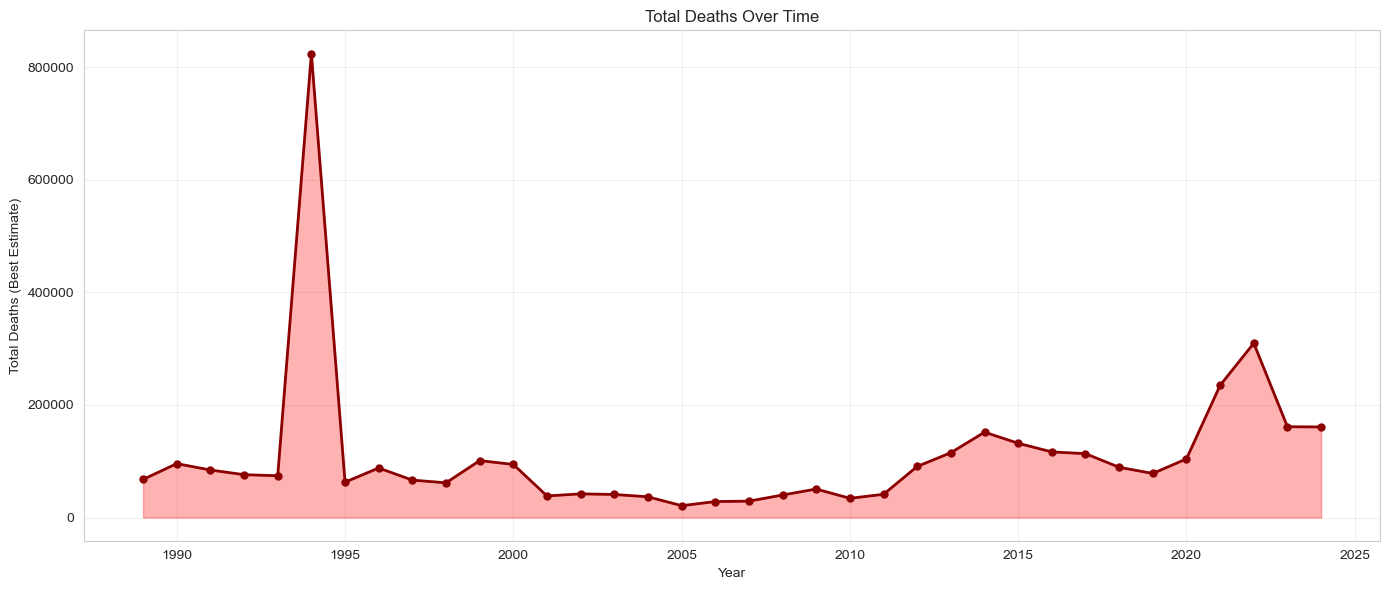

In [24]:
# Total deaths trend over time
deaths_by_year = df.groupby('year')['best'].sum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(deaths_by_year.index, deaths_by_year.values, marker='o', linewidth=2, markersize=5, color='darkred')
ax.fill_between(deaths_by_year.index, deaths_by_year.values, alpha=0.3, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Total Deaths (Best Estimate)')
ax.set_title('Total Deaths Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

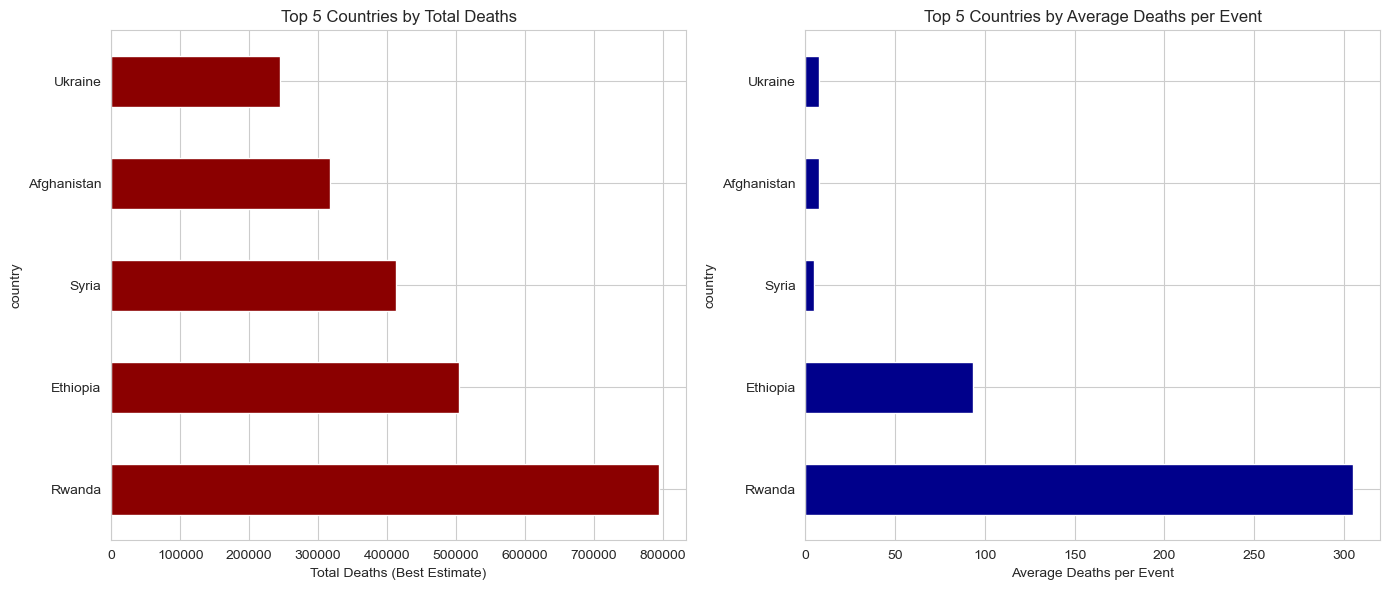

In [27]:
# Geographic heatmap - Top countries and their death counts
country_deaths = df.groupby('country')['best'].agg(['count', 'sum', 'mean']).sort_values('sum', ascending=False).head(5)
country_deaths.columns = ['Events', 'Total_Deaths', 'Avg_Deaths_per_Event']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

country_deaths['Total_Deaths'].plot(kind='barh', ax=axes[0], color='darkred')
axes[0].set_xlabel('Total Deaths (Best Estimate)')
axes[0].set_title('Top 5 Countries by Total Deaths')

country_deaths['Avg_Deaths_per_Event'].plot(kind='barh', ax=axes[1], color='darkblue')
axes[1].set_xlabel('Average Deaths per Event')
axes[1].set_title('Top 5 Countries by Average Deaths per Event')

plt.tight_layout()
plt.show()

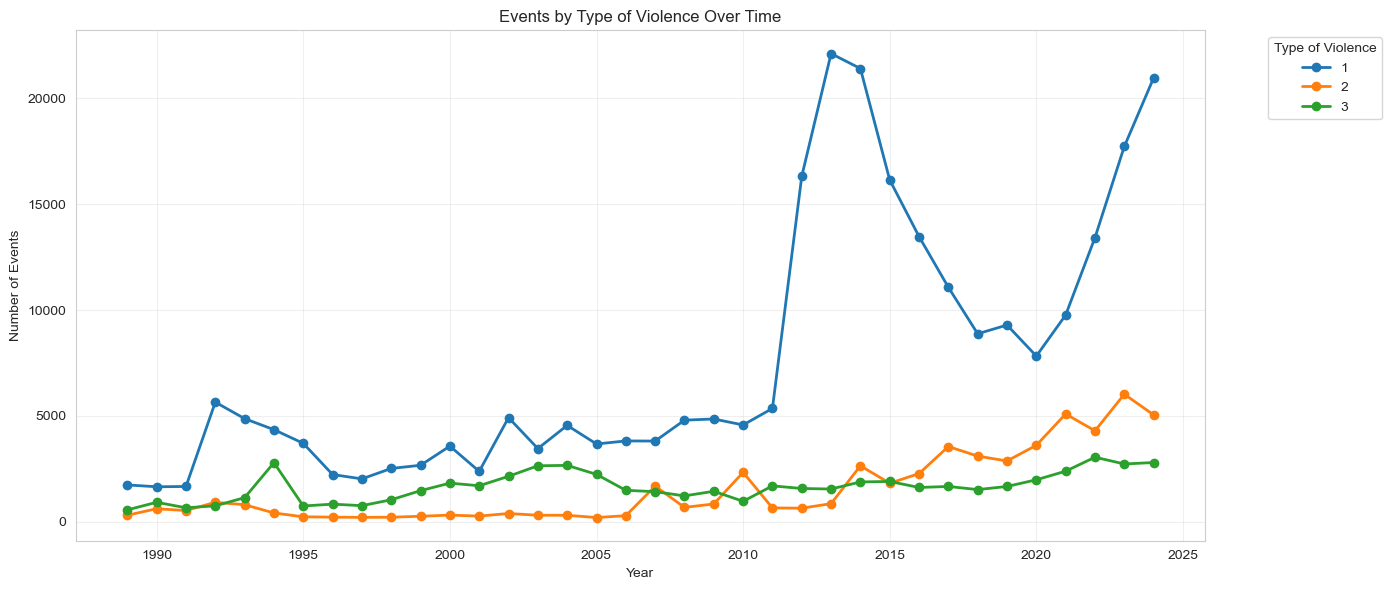

In [28]:
# Events by year and type of violence
violence_by_year = df.groupby(['year', 'type_of_violence']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
violence_by_year.plot(ax=ax, marker='o', linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_title('Events by Type of Violence Over Time')
ax.legend(title='Type of Violence', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary Statistics Table

In [29]:
# Create a comprehensive summary
summary = {
    'Total Records': len(df),
    'Total Columns': len(df.columns),
    'Date Range': f"{df['year'].min()}-{df['year'].max()}",
    'Unique Countries': df['country'].nunique(),
    'Unique Regions': df['region'].nunique(),
    'Conflict Types': df['conflict_dset_id'].nunique(),
    'Total Deaths (Best)': f"{df['best'].sum():,.0f}",
    'Avg Deaths per Event': f"{df['best'].mean():.1f}",
    'Max Deaths per Event': f"{df['best'].max():,.0f}",
    'Total Civilian Deaths': f"{df['deaths_civilians'].sum():,.0f}",
    'Events with Avg Source Count': f"{df['number_of_sources'].mean():.1f}",
    'Missing Values (%)': f"{(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100):.2f}%"
}

print("\n=== COMPREHENSIVE SUMMARY ===")
for key, value in summary.items():
    print(f"{key}: {value}")


=== COMPREHENSIVE SUMMARY ===
Total Records: 385918
Total Columns: 49
Date Range: 1989-2024
Unique Countries: 124
Unique Regions: 5
Conflict Types: 1484
Total Deaths (Best): 3,957,143
Avg Deaths per Event: 10.3
Max Deaths per Event: 121,848
Total Civilian Deaths: 1,474,095
Events with Avg Source Count: 0.8
Missing Values (%): 4.69%
